# **DL LAB 11: 14th Oct, 2025**
## **Name: Soumyadeep Ganguly**
## **Reg No: 24MDT0082**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Bidirectional, Dropout, SimpleRNN
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical


# **Question 1**

In [2]:

VOCAB_SIZE = 20000
MAX_LEN = 500
EMBED_DIM = 100
VALIDATION_SIZE = 1000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

lengths = [len(x) for x in np.concatenate([x_train, x_test])]
print('Min review length:', np.min(lengths))
print('Max review length:', np.max(lengths))
print('Median review length:', np.median(lengths))

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding='post', truncating='post')

x_val = x_train[:VALIDATION_SIZE]
y_val = y_train[:VALIDATION_SIZE]

x_train2 = x_train[VALIDATION_SIZE:]
y_train2 = y_train[VALIDATION_SIZE:]

print('Shapes -> x_train:', x_train2.shape, 'x_val:', x_val.shape, 'x_test:', x_test.shape)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Min review length: 7
Max review length: 2494
Median review length: 176.0
Shapes -> x_train: (24000, 500) x_val: (1000, 500) x_test: (25000, 500)


In [6]:
def build_bi_lstm(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, input_len=MAX_LEN):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=input_len))
    model.add(Bidirectional(LSTM(128, return_sequences=True)))
    model.add(Bidirectional(LSTM(64)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

bi_lstm = build_bi_lstm()
bi_lstm.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_lstm = bi_lstm.fit(
    x_train2, y_train2,
    epochs=5,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 130ms/step - accuracy: 0.5889 - loss: 0.6439 - val_accuracy: 0.4960 - val_loss: 0.6915
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - accuracy: 0.5162 - loss: 0.6902 - val_accuracy: 0.6100 - val_loss: 0.6301
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.6026 - loss: 0.6536 - val_accuracy: 0.6150 - val_loss: 0.6781
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.7039 - loss: 0.6216 - val_accuracy: 0.6520 - val_loss: 0.6432
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 24s 125ms/step - accuracy: 0.7223 - loss: 0.5620 - val_accuracy: 0.7250 - val_loss: 0.5507


In [8]:
test_loss_lstm, test_acc_lstm = bi_lstm.evaluate(x_test, y_test, verbose=1)
print(f"✅ Bi-LSTM Test Accuracy: {test_acc_lstm:.4f}")
print(f"✅ Bi-LSTM Test Loss: {test_loss_lstm:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6983 - loss: 0.5814
✅ Bi-LSTM Test Accuracy: 0.6958
✅ Bi-LSTM Test Loss: 0.5868


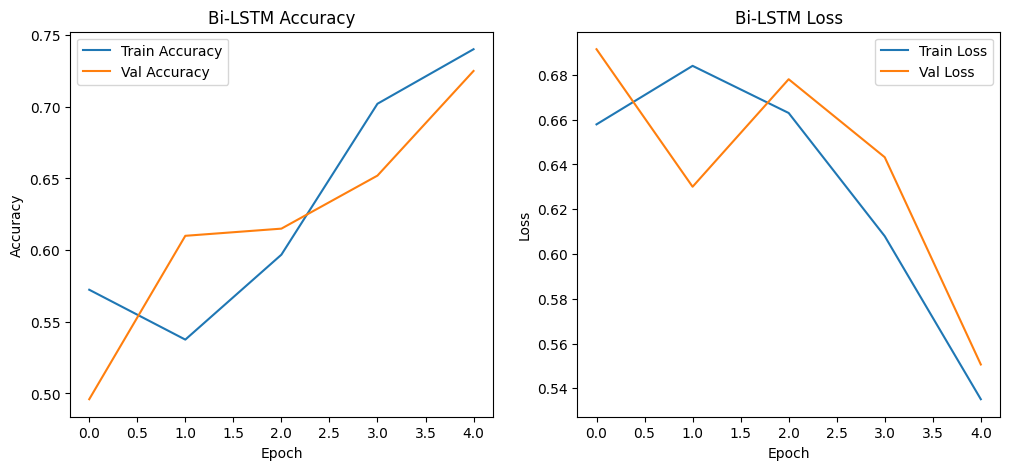

In [9]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('Bi-LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('Bi-LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# **Question 2**

In [11]:
def build_bi_gru(vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, input_len=MAX_LEN):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=input_len))
    model.add(Bidirectional(GRU(128, return_sequences=True)))
    model.add(Bidirectional(GRU(64)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

bi_gru = build_bi_gru()
bi_gru.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_gru = bi_gru.fit(
    x_train2, y_train2,
    epochs=5,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)


test_loss_gru, test_acc_gru = bi_gru.evaluate(x_test, y_test, verbose=1)
print(f"✅ Bi-GRU Test Accuracy: {test_acc_gru:.4f}")
print(f"✅ Bi-GRU Test Loss: {test_loss_gru:.4f}")

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - accuracy: 0.6169 - loss: 0.6218 - val_accuracy: 0.7720 - val_loss: 0.4675
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 23s 120ms/step - accuracy: 0.8671 - loss: 0.3300 - val_accuracy: 0.8710 - val_loss: 0.3151
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 117ms/step - accuracy: 0.9235 - loss: 0.2081 - val_accuracy: 0.8770 - val_loss: 0.3071
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 118ms/step - accuracy: 0.9558 - loss: 0.1285 - val_accuracy: 0.8510 - val_loss: 0.3698
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.9719 - loss: 0.0891 - val_accuracy: 0.8470 - val_loss: 0.3760
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.8331 - loss: 0.4698
✅ Bi-GRU Test Accuracy: 0.8307
✅ Bi-GRU Test Loss: 0.4707


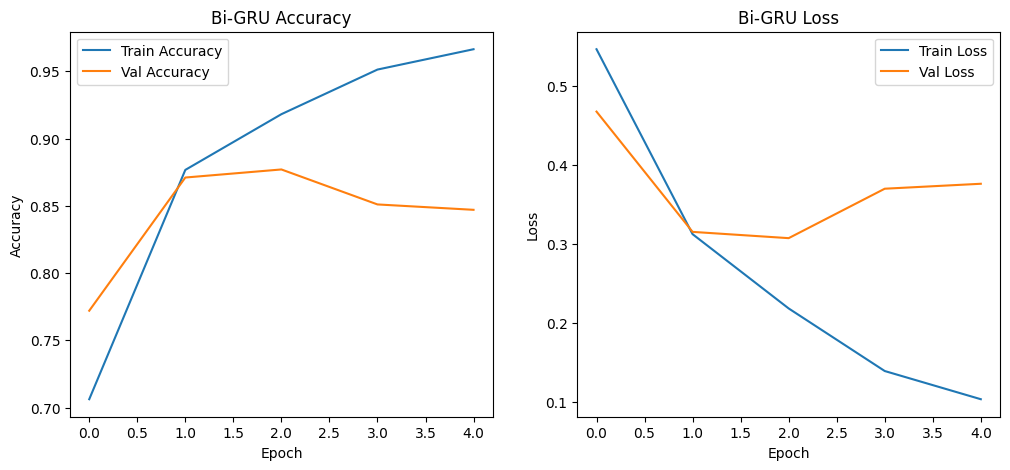

In [13]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Val Accuracy')
plt.title('Bi-GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Val Loss')
plt.title('Bi-GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# **Question 3: RNN next-word prediction**


In [14]:
word_index = imdb.get_word_index()
index_word = {index+3: word for (word, index) in word_index.items()}
index_word[0] = '<PAD>'
index_word[1] = '<START>'
index_word[2] = '<UNK>'
index_word[3] = '<UNUSED>'

raw_texts = []
for seq in x_train[:5000]:
    words = [index_word.get(i, '?') for i in seq if i != 0]
    raw_texts.append(' '.join(words))

print('Number of reconstructed reviews for seq prep:', len(raw_texts))


tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(raw_texts)
sequences = tokenizer.texts_to_sequences(raw_texts)


SEQ_LEN = 10
inputs = []
labels = []
for seq in sequences:
    for i in range(SEQ_LEN, len(seq)):
        inp = seq[i-SEQ_LEN:i]
        lab = seq[i]
        inputs.append(inp)
        labels.append(lab)

inputs = np.array(inputs)
labels = np.array(labels)
print('Total next-word sequences:', inputs.shape)


MAX_SAMPLES = 50000
if inputs.shape[0] > MAX_SAMPLES:
    inputs = inputs[:MAX_SAMPLES]
    labels = labels[:MAX_SAMPLES]

vocab_size_tok = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print('Using vocab size for next-word model:', vocab_size_tok)


def build_next_word_rnn(vocab_size=vocab_size_tok, embed_dim=EMBED_DIM, seq_len=SEQ_LEN):
    model = Sequential()
    model.add(Embedding(vocab_size, embed_dim, input_length=seq_len))
    model.add(SimpleRNN(256))
    model.add(Dense(vocab_size, activation='softmax'))
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

next_rnn = build_next_word_rnn()
next_rnn.summary()


def predict_next_word(model, tokenizer, text, seq_len=SEQ_LEN):
    tokens = tokenizer.texts_to_sequences([text])[0]
    if len(tokens) < seq_len:
        tokens = [0]*(seq_len - len(tokens)) + tokens
    else:
        tokens = tokens[-seq_len:]
    tokens = np.array(tokens).reshape(1, -1)
    preds = model.predict(tokens, verbose=0)[0]
    next_id = np.argmax(preds)
    for word, idx in tokenizer.word_index.items():
        if idx == next_id:
            return word
    return '<UNK>'



1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of reconstructed reviews for seq prep: 5000
Total next-word sequences: (1081538, 10)
Using vocab size for next-word model: 19327


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_next = next_rnn.fit(
    inputs,
    labels,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.0448 - loss: 7.8726 - val_accuracy: 0.0560 - val_loss: 6.8605
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0571 - loss: 6.7059 - val_accuracy: 0.0560 - val_loss: 6.8550
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0576 - loss: 6.6056 - val_accuracy: 0.0640 - val_loss: 6.7812
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0665 - loss: 6.4118 - val_accuracy: 0.0698 - val_loss: 6.7015
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0804 - loss: 6.1286 - val_accuracy: 0.0908 - val_loss: 6.6480
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1050 - loss: 5.8278 - val_accuracy: 0.0910 - val_loss: 6.6859
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1193 - loss: 5.5147 - val_accuracy: 0.0966 - val_loss: 6.7200
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1280 - loss: 5.2033 - val_accuracy: 0

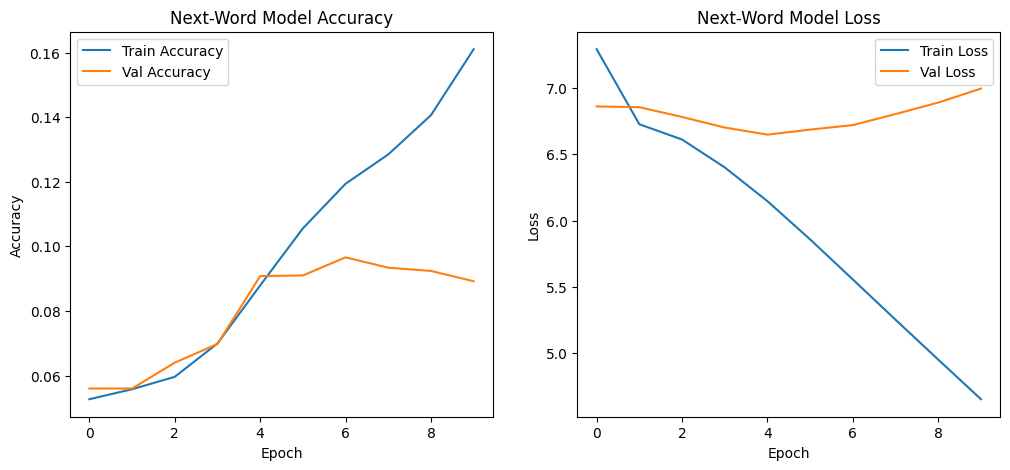

In [16]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_next.history['accuracy'], label='Train Accuracy')
plt.plot(history_next.history['val_accuracy'], label='Val Accuracy')
plt.title('Next-Word Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_next.history['loss'], label='Train Loss')
plt.plot(history_next.history['val_loss'], label='Val Loss')
plt.title('Next-Word Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [17]:
loss, acc = next_rnn.evaluate(inputs, labels, verbose=1)
print(f"✅ Next-Word RNN Training Accuracy: {acc:.4f}")
print(f"✅ Next-Word RNN Training Loss: {loss:.4f}")

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2203 - loss: 4.1899
✅ Next-Word RNN Training Accuracy: 0.2074
✅ Next-Word RNN Training Loss: 4.4655


In [18]:
seed_text = "the movie was really"
predicted_word = predict_next_word(next_rnn, tokenizer, seed_text, SEQ_LEN)
print(f"Input: '{seed_text}'")
print(f"Predicted next word: '{predicted_word}'")

Input: 'the movie was really'
Predicted next word: 'unk'
